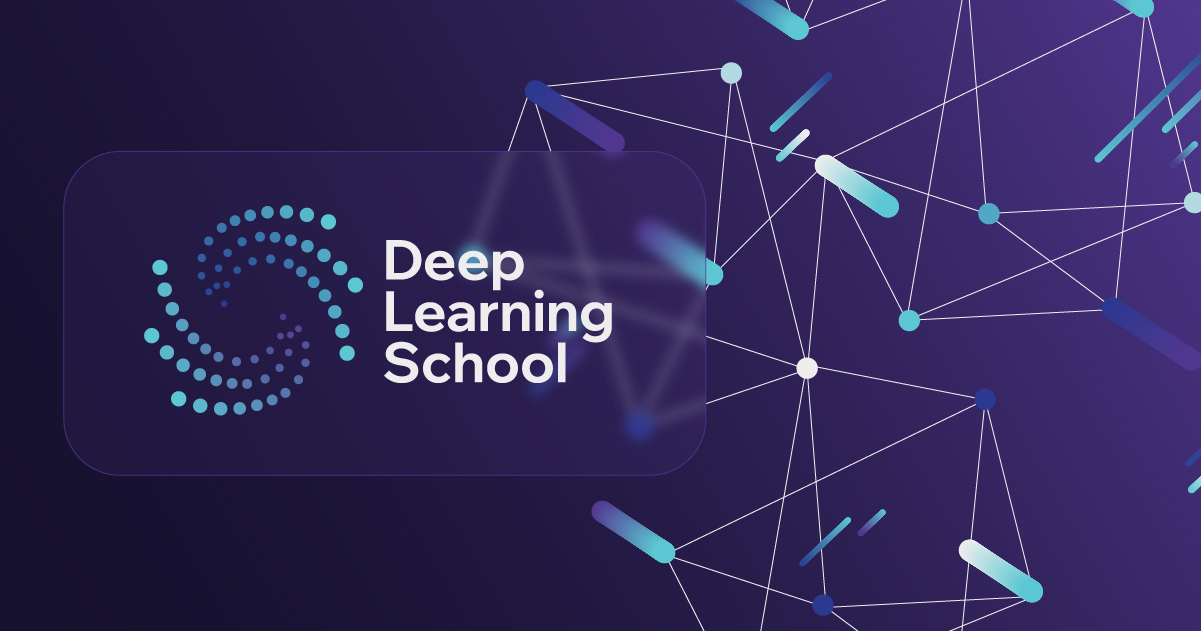


# Домашнее задание "Варианционные автоэнкодеры"

В этом домашнем задании вам предстоит реализовать несколько версий автоэнкодера для работы с изображениями.

Вы научитесь добавлять улыбку на фотографии людей, изменяя их исходное выражение лица с помощью обученной модели. А также, обучите ваш автоэнкодер генерировать изображения рукописных цифр.

# Часть 1. Vanilla Autoencoder (10 баллов)

## 1.1. Подготовка данных (1 балл)


Перед тем, как начинать работу с моделями нужно подготовить данные.

In [ ]:
import numpy as np
from torch.autograd import Variable
from torchvision import datasets
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data_utils
import torch
import matplotlib.pyplot as plt

import os
import pandas as pd
import skimage.io
from skimage.transform import resize

import imageio
from PIL import Image
import kagglehub

%matplotlib inline

In [ ]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

В этом задании вам предстоить работать с датасетом [LFW (Labeled Faces in the Wild)](https://datasets.activeloop.ai/docs/ml/datasets/lfw-dataset/#:~:text=What%20is%20LFW%20Dataset%3F,commercial%20algorithms%20prior%20to%20release).

In [ ]:
# Скачиваем картинки
images_path = kagglehub.dataset_download("jessicali9530/lfw-dataset")
print("Path to dataset files:", images_path)

Using Colab cache for faster access to the 'lfw-dataset' dataset.
Path to dataset files: /kaggle/input/lfw-dataset


In [ ]:
# Скачиваем атрибуты
attrs_path = kagglehub.dataset_download("averkij/lfw-attributes")
print("Path to dataset files:", attrs_path)

Using Colab cache for faster access to the 'lfw-attributes' dataset.
Path to dataset files: /kaggle/input/lfw-attributes


In [ ]:
DATASET_PATH ="/kaggle/input/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled/"
ATTRIBUTES_PATH = "/kaggle/input/lfw-attributes/lfw_attributes.txt"

In [ ]:
def fetch_dataset(dx=80, dy=80, dimx=45, dimy=45):

    df_attrs = pd.read_csv(ATTRIBUTES_PATH, sep='\t', skiprows=1,)
    df_attrs = pd.DataFrame(df_attrs.iloc[:, :-1].values, columns = df_attrs.columns[1:])

    photo_ids = []
    for dirpath, dirnames, filenames in os.walk(DATASET_PATH):
        for fname in filenames:
            if fname.endswith(".jpg"):
                fpath = os.path.join(dirpath, fname)
                photo_id = fname[:-4].replace('_', ' ').split()
                person_id = ' '.join(photo_id[:-1])
                photo_number = int(photo_id[-1])
                photo_ids.append({'person': person_id,'imagenum': photo_number, 'photo_path': fpath})

    photo_ids = pd.DataFrame(photo_ids)
    df = pd.merge(df_attrs,photo_ids,on=('person', 'imagenum'))

    assert len(df) == len(df_attrs), "Потеряны данные при объединении датафреймов!"

    images = df['photo_path'].apply(imageio.imread)\
                                .apply(lambda img:img[dy:-dy, dx:-dx])\
                                .apply(lambda img: np.array(Image.fromarray(img).resize([dimx, dimy])) )

    images = np.stack(images.values).astype('uint8')
    attrs = df.drop(["photo_path","person","imagenum"],axis=1)

    return images, attrs

In [ ]:
# Обратите внимание, что датасет представляет собой не только картинки, но и атрибуты
# Атрибуты понадобятся в конце этого задания

images, attrs = fetch_dataset()


Разбейте датасет изображений и атрибутов на train и val, выведите несколько картинок в output, чтобы посмотреть, как они выглядят, и приведите картинки к тензорам pytorch, чтобы можно было скормить их сети:

In [ ]:
from sklearn.model_selection import train_test_split

idx = np.arange(len(images))

train_idx, val_idx = train_test_split(idx, test_size=0.2, random_state=42, shuffle=True)

train_images, train_attrs = images[train_idx], attrs.iloc[train_idx]
val_images, val_attrs = images[val_idx], attrs.iloc[val_idx]

# train_images = torch.from_numpy(train_images)
# val_images = torch.from_numpy(val_images)

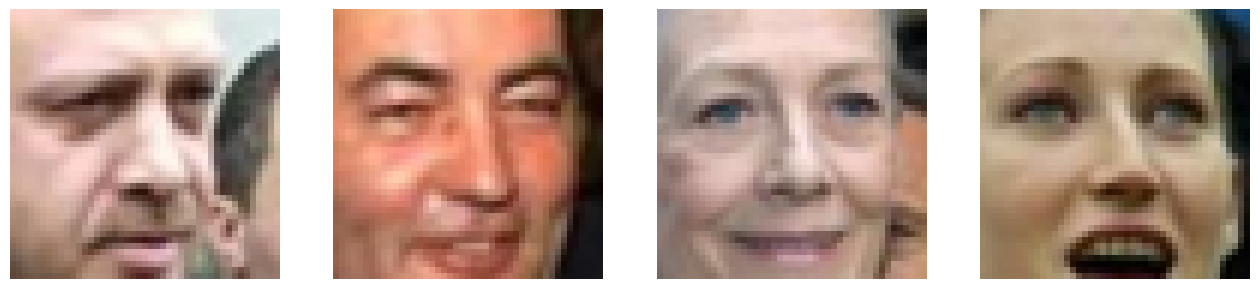

In [ ]:
n = 4
plt.figure(figsize=(16, 4))

for i in range(n):
    plt.subplot(1, n, i + 1)
    plt.imshow(train_images[i])
    plt.axis("off")

plt.show()

In [ ]:
from torch.utils.data import Dataset

class ImageDataset(Dataset):
  def __init__(self, images):
    self.images = images

  def __len__(self):
    return len(self.images)

  def __getitem__(self, idx):
    x = self.images[idx]

    x = torch.from_numpy(x).permute(2, 0, 1)
    x = x.float() / 255.0

    return x

In [ ]:
from torch.utils.data import DataLoader

train_dataset = ImageDataset(train_images)
val_dataset = ImageDataset(val_images)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

dataloaders = {'train': train_loader, 'val': val_loader}

## 1.2. Архитектура модели (2 балла)
В этом разделе вы напишите и обучите обычный автоэнкодер.



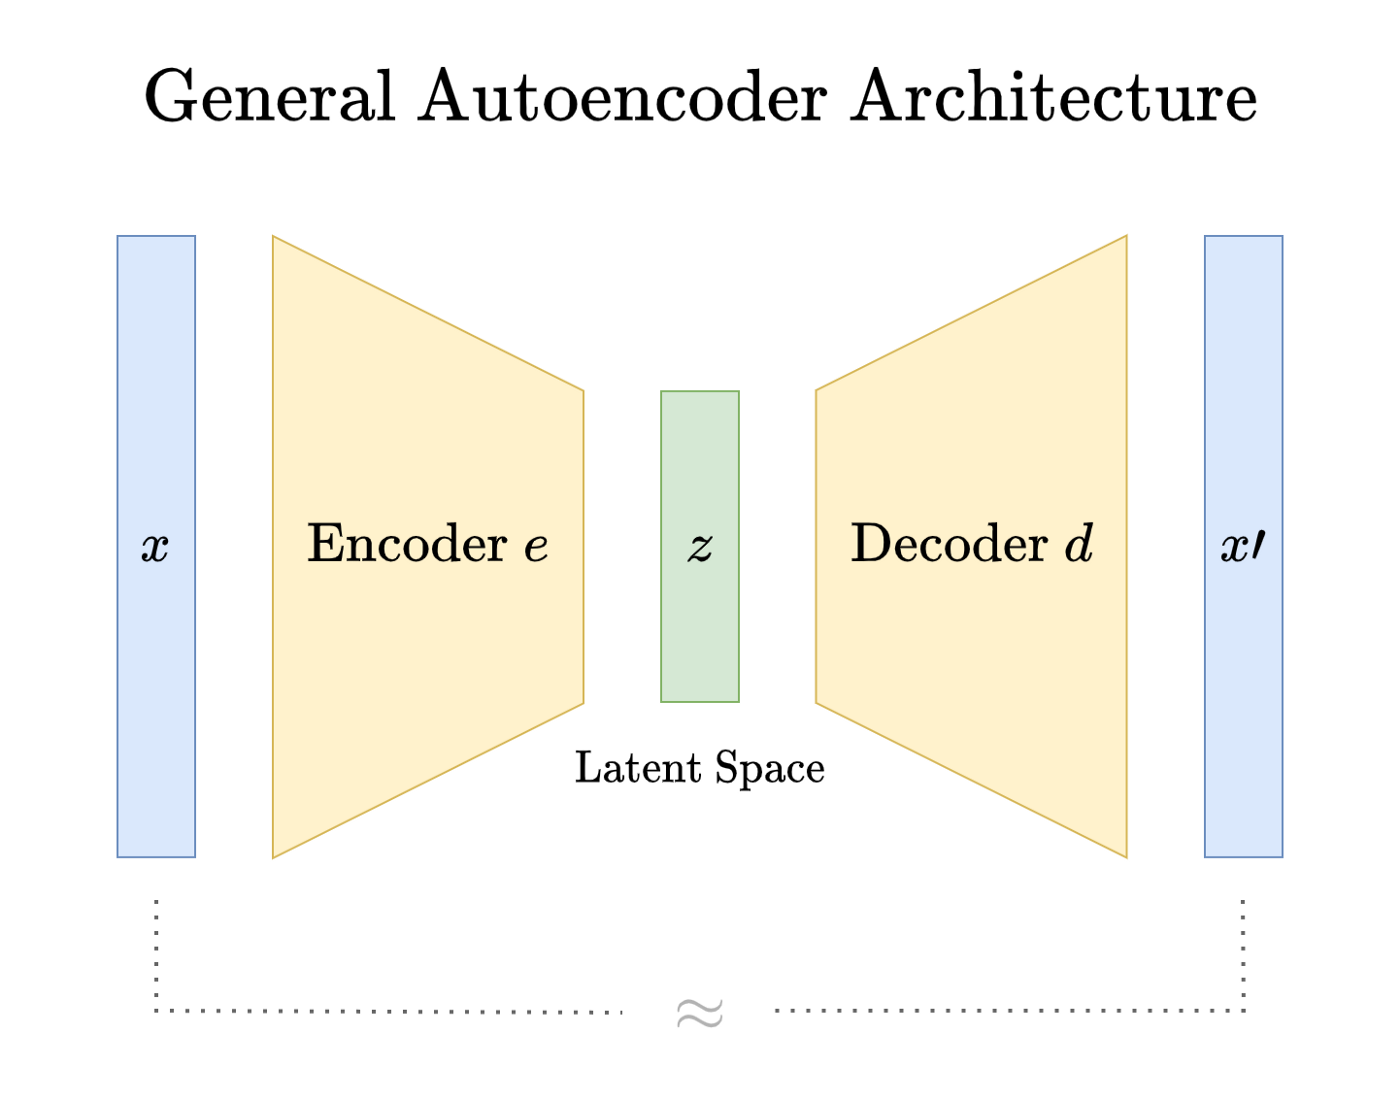

In [ ]:
dim_code = 128

Реализуем autoencoder. Архитектуру (conv, fully-connected, ReLu, etc) можете выбирать сами. Экспериментируйте!



> Начну сразу с козырей: возьму за основу архитектуру SegNet из 6-й домашки



In [ ]:
class EncoderBlock(nn.Module):
  def __init__(self, in_channels, out_channels, depth, kernel_size=3, padding=1):
    super().__init__()

    layers = []
    layers.append(nn.Conv2d(in_channels, out_channels, kernel_size, padding=padding))
    layers.append(nn.BatchNorm2d(out_channels))
    layers.append(nn.ReLU(inplace=False))

    for _ in range(depth - 1):
        layers.append(nn.Conv2d(out_channels, out_channels, kernel_size, padding=padding))
        layers.append(nn.BatchNorm2d(out_channels))
        layers.append(nn.ReLU(inplace=False))

    self.conv = nn.Sequential(*layers)
    self.pool = nn.MaxPool2d(2, 2)

  def forward(self, x):
    x = self.conv(x)
    return self.pool(x)

In [ ]:
class Encoder(nn.Module):
  def __init__(self, in_channels=3, base_ch=64, latent_dim=256):
    super().__init__()

    self.block0 = EncoderBlock(in_channels, base_ch, 2)
    self.block1 = EncoderBlock(base_ch, base_ch * 2, 2)
    self.block2 = EncoderBlock(base_ch * 2, base_ch * 4, 3)
    self.block3 = EncoderBlock(base_ch * 4, base_ch * 8, 3)

    self.to_latent = nn.Sequential(
        nn.AdaptiveAvgPool2d((1, 1)),
        nn.Flatten(),
        nn.Linear(base_ch * 8, latent_dim)
    )

  def forward(self, x):
    x = self.block0(x)
    x = self.block1(x)
    x = self.block2(x)
    x = self.block3(x)
    return self.to_latent(x)

In [ ]:
class Decoder(nn.Module):
  def __init__(self, latent_dim=256, out_channels=3, base_ch=64):
    super().__init__()

    self.fc = nn.Linear(latent_dim, base_ch * 8 * 6 * 6)

    self.net = nn.Sequential(
      nn.Unflatten(1, (base_ch * 8, 6, 6)),

      nn.Upsample(scale_factor=2),
      nn.Conv2d(base_ch * 8, base_ch * 4, 3, padding=1),
      nn.BatchNorm2d(base_ch * 4),
      nn.ReLU(True),

      nn.Upsample(scale_factor=2),
      nn.Conv2d(base_ch * 4, base_ch * 2, 3, padding=1),
      nn.BatchNorm2d(base_ch * 2),
      nn.ReLU(True),

      nn.Upsample(scale_factor=2),
      nn.Conv2d(base_ch * 2, base_ch, 3, padding=1),
      nn.BatchNorm2d(base_ch),
      nn.ReLU(True),

      nn.Conv2d(base_ch, out_channels, 3, padding=1),
      nn.Sigmoid()
    )

  def forward(self, z):
    x = self.fc(z)
    x = self.net(x)
    return x[:, :, :45, :45]

In [ ]:
class Autoencoder(nn.Module):
  def __init__(self, in_channels=3, out_channels=3, base_ch=64, latent_dim=256):
    super().__init__()

    self.encoder = Encoder(in_channels, base_ch, latent_dim)
    self.decoder = Decoder(latent_dim, out_channels, base_ch)

  def forward(self, x):
    z = self.encoder(x)
    recon = self.decoder(z)
    return recon, z

In [ ]:
criterion = nn.MSELoss()
autoencoder = Autoencoder()
optimizer = torch.optim.Adam(autoencoder.parameters(), lr = 1e-3)

## 1.3 Обучение (2 балла)

Осталось написать код обучения автоэнкодера. При этом было бы неплохо в процессе иногда смотреть, как автоэнкодер реконструирует изображения на данном этапе обучения. Наример, после каждой эпохи (прогона train выборки через автоэнкодер) можно смотреть, какие реконструкции получились для каких-то изображений val выборки.

А, ну еще было бы неплохо выводить графики train и val лоссов в процессе тренировки =)

In [ ]:
from tqdm.notebook import tqdm

In [ ]:
def fit_one_epoch(model, train_dataloader, optimizer, loss_func):
  '''
  args:
    model - модель для обучения
    train_dataloader - loader с выборкой для обучения модели
    optimizer - оптимизатор, взятый из модуля `torch.optim`
    loss_func - функция потерь, взятая из модуля `torch.nn`

  функция возвращает метрику accuracy по эпохе на данных из train_dataloader
  '''

  model.train()
  avg_loss = 0
  visualized = False

  for X_batch in tqdm(train_dataloader):
    X_batch = X_batch.to(DEVICE)

    optimizer.zero_grad()
    outp, latent = model(X_batch)

    if not visualized:
      visualized = True
      visualize(X_batch, outp)

    loss = loss_func(outp, X_batch)
    loss.backward()
    optimizer.step()

    avg_loss += loss.item()

  return avg_loss / len(train_dataloader)

In [ ]:
def eval_one_epoch(model, val_dataloader, loss_func):
  model.eval()
  avg_loss = 0

  visualized = False

  with torch.no_grad():
    for X_batch in tqdm(val_dataloader):
      X_batch = X_batch.to(DEVICE)

      reconstructed, latent = model(X_batch)

      loss = loss_func(reconstructed, X_batch)

      avg_loss += loss.item()

      if not visualized:
        visualized = True
        visualize(X_batch, reconstructed)

    avg_loss = avg_loss / len(val_dataloader)

  return avg_loss

In [ ]:
def visualize(X_batch, reconstructed, n=1):
  plt.figure(figsize=(6, 2*n))

  for i in range(n):
    img = X_batch[i].detach().permute(1,2,0).cpu().numpy()

    rec = reconstructed[i].detach()
    # rec = torch.sigmoid(rec)
    rec = rec.permute(1,2,0).cpu().numpy()

    img = img.clip(0, 1)
    rec = rec.clip(0, 1)

    plt.subplot(n, 2, 2*i + 1)
    plt.imshow(img)
    plt.title("Input")
    plt.axis("off")

    plt.subplot(n, 2, 2*i + 2)
    plt.imshow(rec)
    plt.title("Reconstruction")
    plt.axis("off")

  plt.tight_layout()
  plt.show()

In [ ]:
def train_func(model, num_epochs, dataloaders, optimizer, loss_func):
  '''
  args:
    model - модель для обучения
    num_epochs - количество эпох
    dataloaders - словарь loader'ов с обучающей и валидационной выборками
    optimizer - оптимизатор, взятый из модуля `torch.optim`
    loss_func - функция потерь, взятая из модуля `torch.nn`

  функция возвращает loss на обучающей и валидационной выборках на каждой эпохе, а также метрику IoU на валидационной выборке
  '''
  model = model.to(DEVICE)
  score = {"train_loss": [], "val_loss": []}
  for epoch in range(num_epochs):
    print(f"\nEpoch: {epoch+1}")

    loss_train = fit_one_epoch(model = model, train_dataloader = dataloaders['train'], optimizer = optimizer, loss_func = loss_func)
    print(f"Loss train: {loss_train}\n")

    loss_val = eval_one_epoch(model = model, val_dataloader = dataloaders['val'], loss_func=loss_func)
    print(f"Loss valid: {loss_val}\n")


    score['train_loss'].append(loss_train)
    score['val_loss'].append(loss_val)
  return model, score


Epoch: 1


  0%|          | 0/1315 [00:00<?, ?it/s]

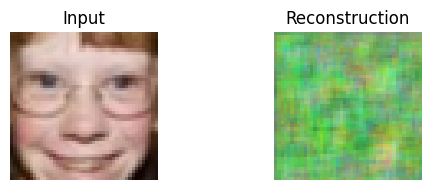

Loss train: 0.014720889357602076



  0%|          | 0/329 [00:00<?, ?it/s]

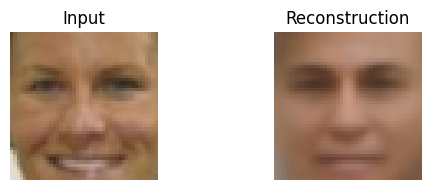

Loss valid: 0.011550608470379219


Epoch: 2


  0%|          | 0/1315 [00:00<?, ?it/s]

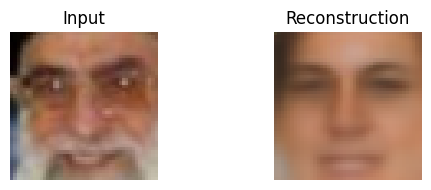

Loss train: 0.010312172626021243



  0%|          | 0/329 [00:00<?, ?it/s]

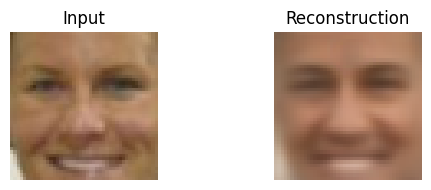

Loss valid: 0.00877571998073473


Epoch: 3


  0%|          | 0/1315 [00:00<?, ?it/s]

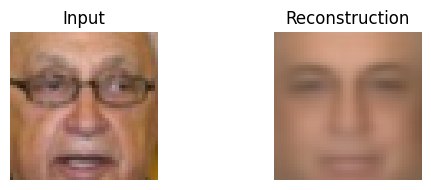

Loss train: 0.008880474238865389



  0%|          | 0/329 [00:00<?, ?it/s]

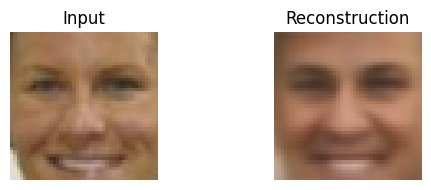

Loss valid: 0.008210940970147544


Epoch: 4


  0%|          | 0/1315 [00:00<?, ?it/s]

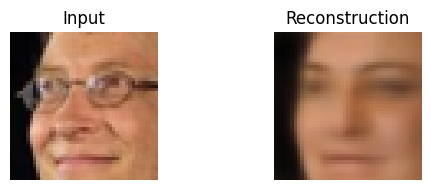

Loss train: 0.00809698405254193



  0%|          | 0/329 [00:00<?, ?it/s]

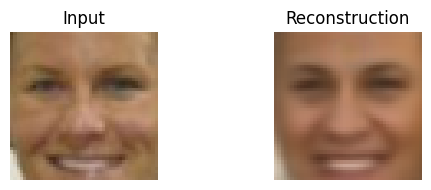

Loss valid: 0.007978608040563695


Epoch: 5


  0%|          | 0/1315 [00:00<?, ?it/s]

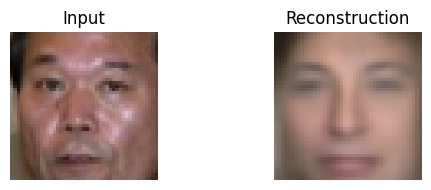

Loss train: 0.007389062429873889



  0%|          | 0/329 [00:00<?, ?it/s]

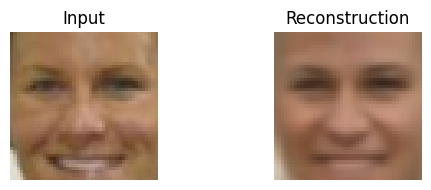

Loss valid: 0.007022312889017142


Epoch: 6


  0%|          | 0/1315 [00:00<?, ?it/s]

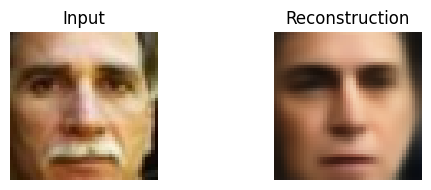

Loss train: 0.006887428719769923



  0%|          | 0/329 [00:00<?, ?it/s]

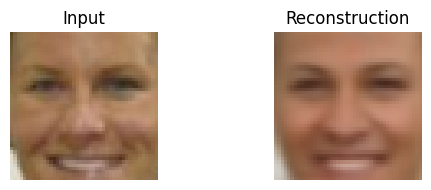

Loss valid: 0.006220516113219018


Epoch: 7


  0%|          | 0/1315 [00:00<?, ?it/s]

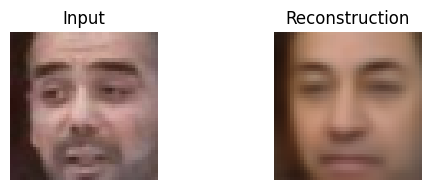

Loss train: 0.006444600248751815



  0%|          | 0/329 [00:00<?, ?it/s]

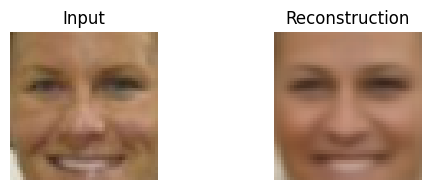

Loss valid: 0.005615799064326204


Epoch: 8


  0%|          | 0/1315 [00:00<?, ?it/s]

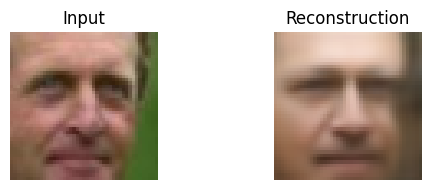

Loss train: 0.006125579020468794



  0%|          | 0/329 [00:00<?, ?it/s]

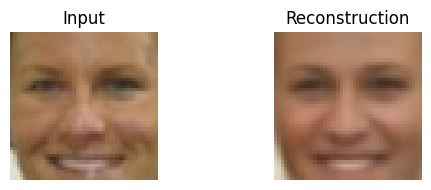

Loss valid: 0.005459279801390816


Epoch: 9


  0%|          | 0/1315 [00:00<?, ?it/s]

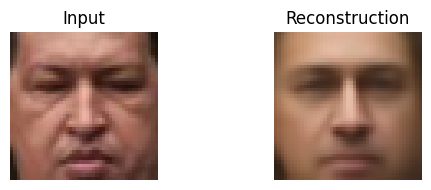

Loss train: 0.005903900753062204



  0%|          | 0/329 [00:00<?, ?it/s]

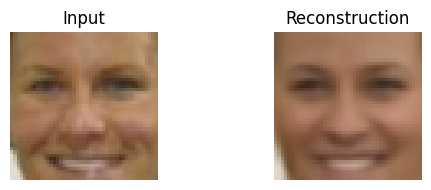

Loss valid: 0.005608481127134663


Epoch: 10


  0%|          | 0/1315 [00:00<?, ?it/s]

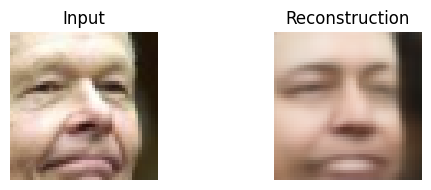

Loss train: 0.005636536955351839



  0%|          | 0/329 [00:00<?, ?it/s]

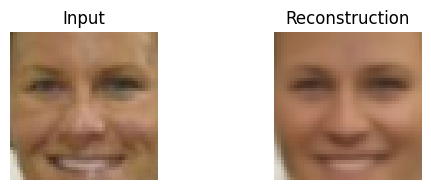

Loss valid: 0.004935092997587198



In [ ]:
autoencoder, autoencoder_score = train_func(autoencoder, 10, dataloaders, optimizer, criterion)

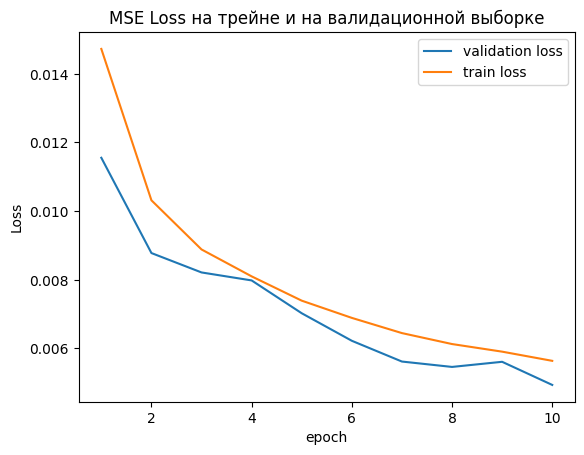

In [ ]:
plt.plot(range(1, 11), autoencoder_score['val_loss'], label='validation loss')
plt.plot(range(1, 11), autoencoder_score['train_loss'], label='train loss')

plt.title('MSE Loss на трейне и на валидационной выборке')
plt.xlabel('epoch')
plt.ylabel('Loss')
plt.legend()

Что вы можете сказать про результат?

> Видно, что картинки всегда получаются замыленными, у людей часто пропадают очки с лица или другие аксессуары

## 1.4. Sampling (2 балла)

Давайте теперь будем не просто брать картинку, прогонять ее через автоэнкодер и получать реконструкцию, а попробуем создать что-то НОВОЕ!

Давайте возьмем и подсунем декодеру какие-нибудь сгенерированные нами векторы (например, из нормального распределения) и посмотрим на результат реконструкции декодера:

__Подсказка:__ Если вместо лиц у вас выводится непонятно что, попробуйте посмотреть, как выглядят латентные векторы картинок из датасета. Так как в обучении нейронных сетей есть определенная доля рандома, векторы латентного слоя могут быть распределены НЕ как `np.random.randn(25, <latent_space_dim>)`. А чтобы у нас получались лица при запихивании вектора декодеру, вектор должен быть распределен так же, как латентные векторы реальных фоток. Так что в таком случае придется рандом немного подогнать.

In [ ]:
# сгенерируем 25 рандомных векторов размера latent_space
z = torch.randn(25, 256, device=DEVICE)
new_images = autoencoder.decoder(z)

In [ ]:
import torchvision.utils as vutils

def show_images_grid(images, nrow=8):
  images = images.detach().cpu()
  grid = vutils.make_grid(
      images,
      nrow=nrow,
      padding=2,
      normalize=True
  )

  plt.figure(figsize=(nrow * 2, (len(images) // nrow + 1) * 2))
  plt.imshow(grid.permute(1, 2, 0))
  plt.axis("off")

  plt.show()

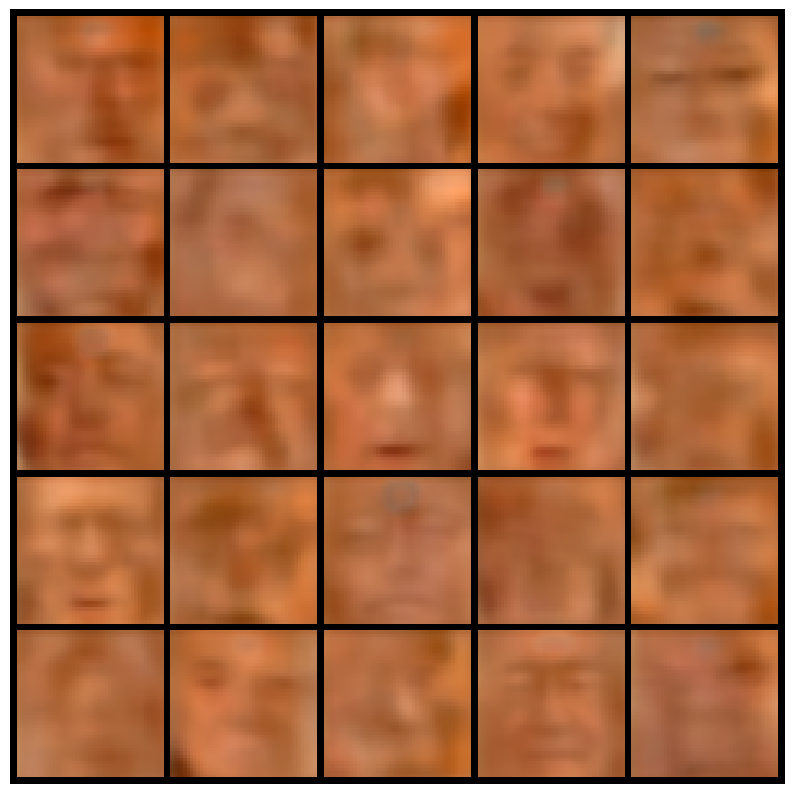

In [ ]:
show_images_grid(new_images, 5)

> Какие-то черты лица прослеживаются, но все равно латенты не самые лучшие.

> Чтобы улучшить ситуацию, посмотрим на распределение латентных векторов и будем семплировать из него.

In [ ]:
def get_latents(dataloader):
  autoencoder.eval()
  latents = []
  with torch.no_grad():
    for X_batch in dataloader:
      X_batch = X_batch.to(DEVICE)
      _, z  = autoencoder(X_batch)
      latents.append(z.cpu())

  latents = torch.cat(latents, dim=0)
  return latents

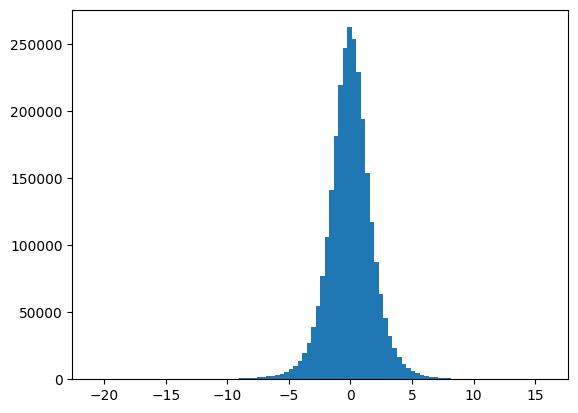

In [ ]:
plt.hist(latents.numpy().flatten(), bins=100)
plt.show()

In [ ]:
latents = get_latents(dataloaders['train'])
mu = latents.mean(dim=0)
std = latents.std(dim=0)

z = torch.randn(25, 256) * std + mu

new_images = autoencoder.decoder(z.to(DEVICE))

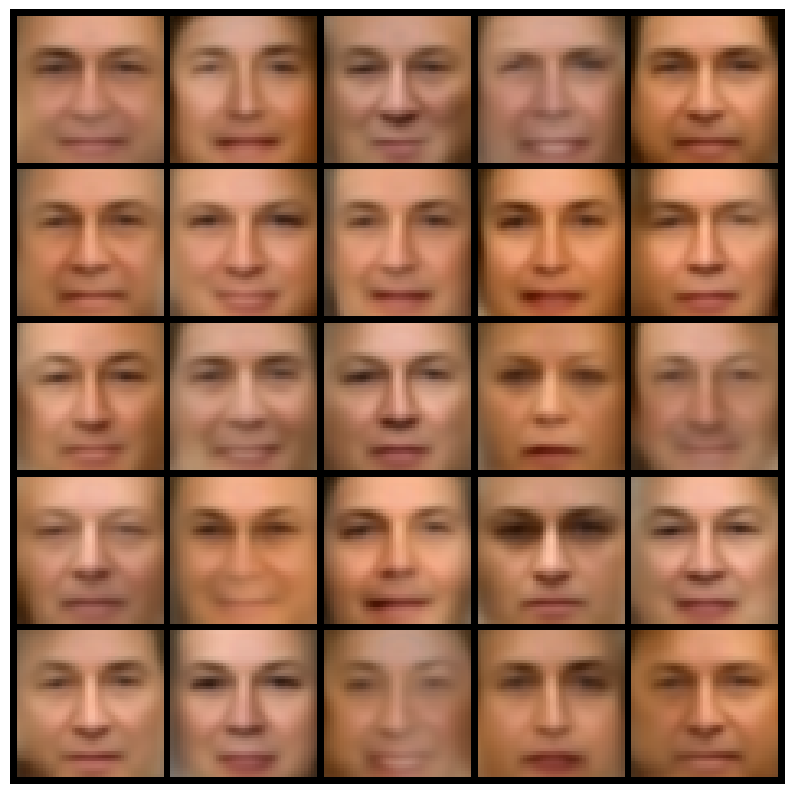

In [ ]:
show_images_grid(new_images, 5)

> Намного лучше!!


## 1.5 Time to make fun! (3 балла)

Давайте научимся пририсовывать людям улыбки =)

<img src="https://i.imgur.com/tOE9rDK.png" alt="linear" width="700" height="400">

План такой:

1. Нужно выделить "вектор улыбки": для этого нужно из выборки изображений найти несколько (~15) людей с улыбками и столько же без.

Найти людей с улыбками вам поможет файл с атрибутами, скачанный вместе с картинками. В нем указаны имена изображений и присутствубщие атрибуты (улыбки, очки и прочее интересное).

2. Вычислить латентный вектор для всех улыбающихся людей (прогнать их через encoder) и то же для всех грустненьких.

3. Вычислить, собственно, вектор улыбки -- посчитать разность между средним латентным вектором улыбающихся людей и средним латентным вектором грустных людей.

4. А теперь приделаем улыбку грустному человеку: добавим полученный в пункте 3 вектор к латентному вектору грустного человека и прогоним полученный вектор через decoder. Получим того же человека, но уже не грустненького!

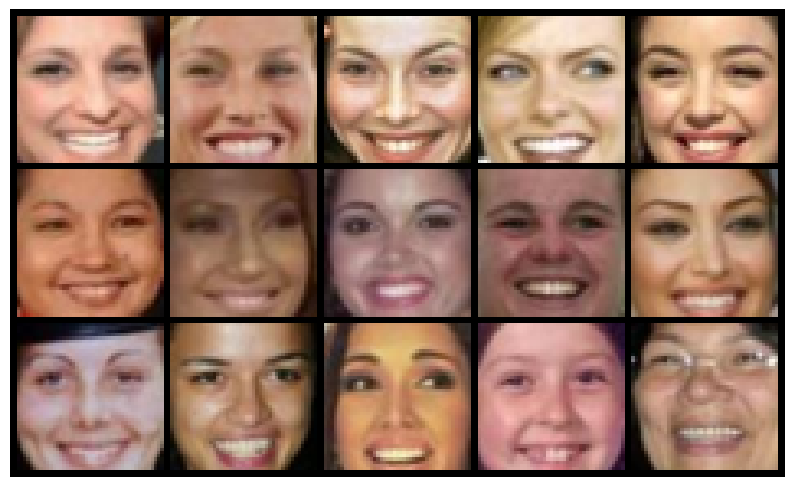

In [ ]:
smiling_people = images[attrs['Smiling'].sort_values(ascending=False).head(15).index]
imgs = torch.from_numpy(smiling_people).permute(0, 3, 1, 2).float() / 255.0
show_images_grid(imgs, 5)

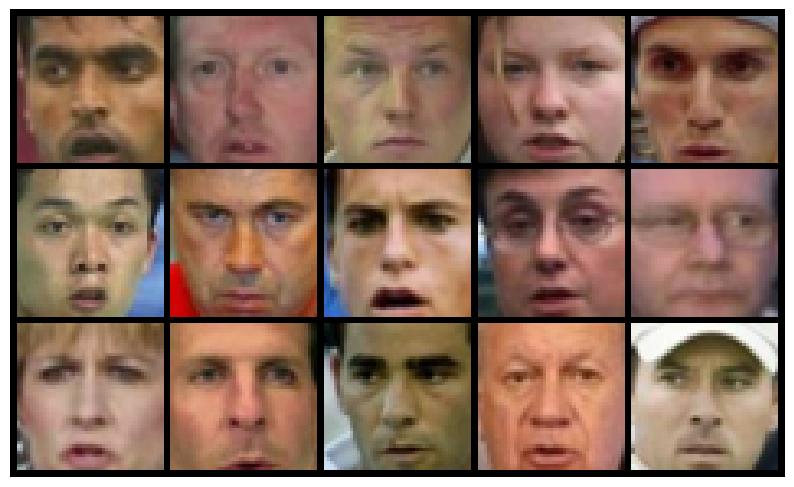

In [ ]:
not_smiling_people = images[attrs['Smiling'].sort_values(ascending=True).head(15).index]
imgs = torch.from_numpy(not_smiling_people).permute(0, 3, 1, 2).float() / 255.0
show_images_grid(imgs, 5)

In [ ]:
smiling_people = DataLoader(ImageDataset(smiling_people))
z_smiling = get_latents(smiling_people)

In [ ]:
not_smiling_people = DataLoader(ImageDataset(not_smiling_people))
z_not_smiling = get_latents(not_smiling_people)

In [ ]:
smile = z_smiling.mean(dim=0) - z_not_smiling.mean(dim=0)

In [ ]:
z_new_smiling = z_not_smiling + smile
new_smiling_people = autoencoder.decoder(z_new_smiling.to(DEVICE))

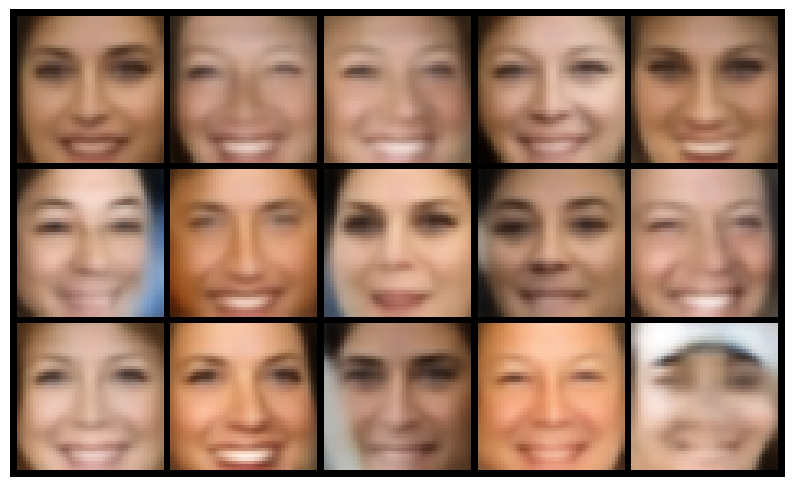

In [ ]:
show_images_grid(new_smiling_people, 5)

> Немного поменялась внешность у наших героев, но хотя бы теперь они улыбаются :)

Вуаля! Вы восхитительны!

Теперь вы можете пририсовывать людям не только улыбки, но и много чего другого -- закрывать/открывать глаза, пририсовывать очки... В общем, все, на что хватит фантазии и на что есть атрибуты в `attrs`:)

# Часть 2: Variational Autoencoder (10 баллов)

Займемся обучением вариационных автоэнкодеров — проапгрейженной версии AE. Обучать будем на датасете MNIST, содержащем написанные от руки цифры от 0 до 9

In [ ]:
from torchvision import transforms

batch_size = 32
# MNIST Dataset
train_dataset = datasets.MNIST(root='./mnist_data/', train=True, transform=transforms.ToTensor(), download=True)
test_dataset = datasets.MNIST(root='./mnist_data/', train=False, transform=transforms.ToTensor(), download=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 505kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.60MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.7MB/s]


In [ ]:
from torch.utils.data import DataLoader

def images_only_collate(batch):
    images, _ = zip(*batch)
    return torch.stack(images, 0)

train_loader_no_labels = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    collate_fn=images_only_collate
)

test_loader_no_labels = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    collate_fn=images_only_collate
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [ ]:
dataloaders_mnist = {'train' : train_loader_no_labels, 'val': test_loader_no_labels}

In [ ]:
dataloaders_mnist_with_labels = {'train' : train_loader, 'val': test_loader}

## 2.1 Архитектура модели и обучение (2 балла)

Реализуем VAE. Архитектуру (conv, fully-connected, ReLu, etc) можете выбирать сами. Рекомендуем пользоваться более сложными моделями, чем та, что была на семинаре:) Экспериментируйте!

> Немного модифицируем раннее написанную архитектуру для обычного автокодировщика: теперь энкодер должен будет возвращать параметры распределения

In [ ]:
class Encoder(nn.Module):
  def __init__(self, in_channels=1, base_ch=64, latent_dim=256):
    super().__init__()

    self.block0 = EncoderBlock(in_channels, base_ch, 2)
    self.block1 = EncoderBlock(base_ch, base_ch * 2, 2)
    self.block2 = EncoderBlock(base_ch * 2, base_ch * 4, 3)
    self.block3 = EncoderBlock(base_ch * 4, base_ch * 8, 3)

    self.pool = nn.AdaptiveAvgPool2d((1, 1))
    self.flatten = nn.Flatten()

    self.fc_mu = nn.Linear(base_ch * 8, latent_dim)
    self.fc_logvar = nn.Linear(base_ch * 8, latent_dim)

  def forward(self, x):
    x = self.block0(x)
    x = self.block1(x)
    x = self.block2(x)
    x = self.block3(x)

    x = self.pool(x)
    x = self.flatten(x)

    mu = self.fc_mu(x)
    logvar = self.fc_logvar(x)

    return mu, logvar

In [ ]:
class Decoder(nn.Module):
  def __init__(self, latent_dim=256, out_channels=1, base_ch=64):
    super().__init__()

    self.fc = nn.Linear(latent_dim, base_ch * 8 * 4 * 4)

    self.net = nn.Sequential(
      nn.Unflatten(1, (base_ch * 8, 4, 4)),

      nn.Upsample(scale_factor=2),
      nn.Conv2d(base_ch * 8, base_ch * 4, 3, padding=1),
      nn.BatchNorm2d(base_ch * 4),
      nn.ReLU(True),

      nn.Upsample(scale_factor=2),
      nn.Conv2d(base_ch * 4, base_ch * 2, 3, padding=1),
      nn.BatchNorm2d(base_ch * 2),
      nn.ReLU(True),

      nn.Upsample(scale_factor=2),
      nn.Conv2d(base_ch * 2, base_ch, 3, padding=1),
      nn.BatchNorm2d(base_ch),
      nn.ReLU(True),

      nn.Conv2d(base_ch, out_channels, 3, padding=1),
      nn.Sigmoid()
    )

  def forward(self, z):
    x = self.fc(z)
    x = self.net(x)
    return x[:, :, :28, :28]


In [ ]:
def reparameterize(mu, logvar):
  std = torch.exp(0.5 * logvar)
  eps = torch.randn_like(std)
  return mu + eps * std

In [ ]:
class VAE(nn.Module):
  def __init__(self, in_channels=1, out_channels=1, base_ch=64, latent_dim=256):
    super().__init__()

    self.encoder = Encoder(in_channels, base_ch, latent_dim)
    self.decoder = Decoder(latent_dim, out_channels, base_ch)

  def forward(self, x):
    mu, logvar = self.encoder(x)
    z = reparameterize(mu, logvar)
    recon = self.decoder(z)
    return recon, mu, logvar

Определим лосс и его компоненты для VAE:

Надеюсь, вы уже прочитали материал в towardsdatascience (или еще где-то) про VAE и знаете, что лосс у VAE состоит из двух частей: KL и log-likelihood.

Общий лосс будет выглядеть так:

$$\mathcal{L} = -D_{KL}(q_{\phi}(z|x)||p(z)) + \log p_{\theta}(x|z)$$

Формула для KL-дивергенции:

$$D_{KL} = -\frac{1}{2}\sum_{i=1}^{dimZ}(1+log(\sigma_i^2)-\mu_i^2-\sigma_i^2)$$

В качестве log-likelihood возьмем привычную нам кросс-энтропию.

In [ ]:
def KL_divergence(mu, logvar):
    """
    часть функции потерь, которая отвечает за "близость" латентных представлений разных людей
    """
    loss = -0.5 * torch.sum(1 + logvar - logvar.exp() - mu**2)
    return loss

def log_likelihood(x, reconstruction):
    """
    часть функции потерь, которая отвечает за качество реконструкции (как mse в обычном autoencoder)
    """
    loss = F.binary_cross_entropy(reconstruction, x, reduction="sum")
    return loss

def loss_vae(x, mu, logvar, reconstruction):
    batch_size = x.size(0)
    return (KL_divergence(mu, logvar) + log_likelihood(x, reconstruction)) / batch_size

И обучим модель:

In [ ]:
def fit_one_epoch(model, train_dataloader, optimizer, loss_func):
  '''
  args:
    model - модель для обучения
    train_dataloader - loader с выборкой для обучения модели
    optimizer - оптимизатор, взятый из модуля `torch.optim`
    loss_func - функция потерь, взятая из модуля `torch.nn`

  функция возвращает метрику accuracy по эпохе на данных из train_dataloader
  '''

  model.train()
  avg_loss = 0
  visualized = False

  for X_batch in tqdm(train_dataloader):
    X_batch = X_batch.to(DEVICE)

    optimizer.zero_grad()
    outp, mu, logvar = model(X_batch)

    if not visualized:
      visualized = True
      visualize(X_batch, outp)

    loss = loss_func(X_batch, mu, logvar, outp)
    loss.backward()
    optimizer.step()

    avg_loss += loss.item()

  return avg_loss / len(train_dataloader)

In [ ]:
def eval_one_epoch(model, val_dataloader, loss_func):
  model.eval()
  avg_loss = 0

  visualized = False

  with torch.no_grad():
    for X_batch in tqdm(val_dataloader):
      X_batch = X_batch.to(DEVICE)

      reconstructed, mu, logvar = model(X_batch)

      loss = loss_func(X_batch, mu, logvar, reconstructed)

      avg_loss += loss.item()

      if not visualized:
        visualized = True
        visualize(X_batch, reconstructed)

    avg_loss = avg_loss / len(val_dataloader)

  return avg_loss

In [ ]:
criterion = loss_vae
autoencoder = VAE()
optimizer = torch.optim.Adam(autoencoder.parameters(), lr = 1e-3)


Epoch: 1


  0%|          | 0/1875 [00:00<?, ?it/s]

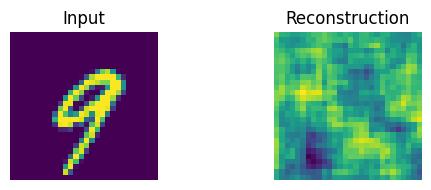

Loss train: 163.7221407796224



  0%|          | 0/313 [00:00<?, ?it/s]

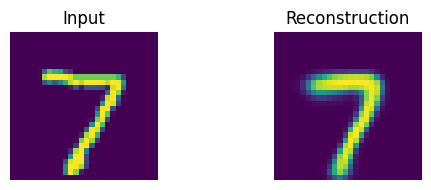

Loss valid: 133.6588073827969


Epoch: 2


  0%|          | 0/1875 [00:00<?, ?it/s]

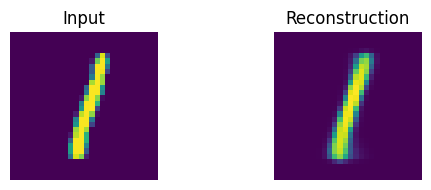

Loss train: 122.87901935628256



  0%|          | 0/313 [00:00<?, ?it/s]

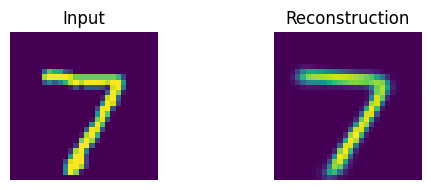

Loss valid: 114.17983094724222


Epoch: 3


  0%|          | 0/1875 [00:00<?, ?it/s]

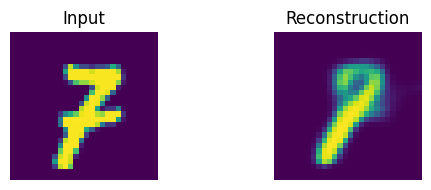

Loss train: 111.07378214518229



  0%|          | 0/313 [00:00<?, ?it/s]

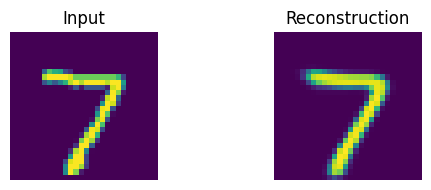

Loss valid: 105.223921486364


Epoch: 4


  0%|          | 0/1875 [00:00<?, ?it/s]

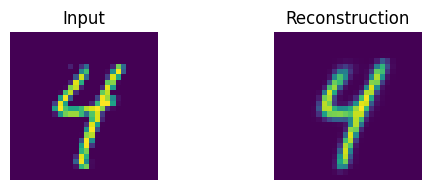

Loss train: 106.35072573649089



  0%|          | 0/313 [00:00<?, ?it/s]

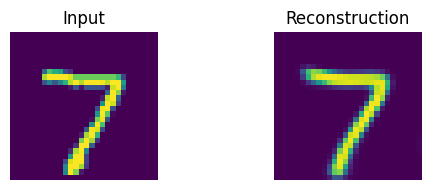

Loss valid: 102.87968179136038


Epoch: 5


  0%|          | 0/1875 [00:00<?, ?it/s]

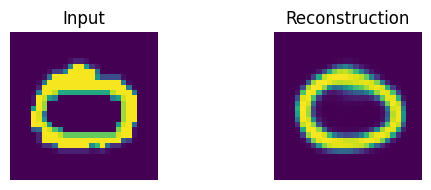

Loss train: 104.03101466878255



  0%|          | 0/313 [00:00<?, ?it/s]

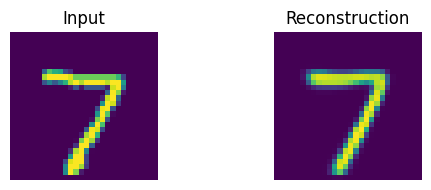

Loss valid: 103.6027803512427


Epoch: 6


  0%|          | 0/1875 [00:00<?, ?it/s]

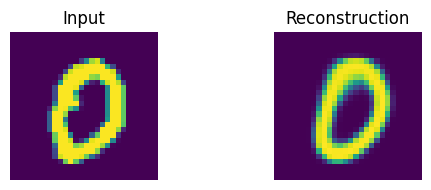

Loss train: 102.18196581624349



  0%|          | 0/313 [00:00<?, ?it/s]

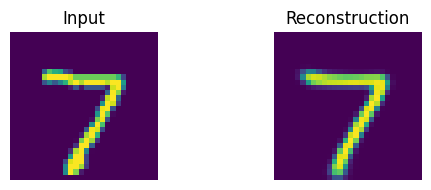

Loss valid: 100.21053994273225


Epoch: 7


  0%|          | 0/1875 [00:00<?, ?it/s]

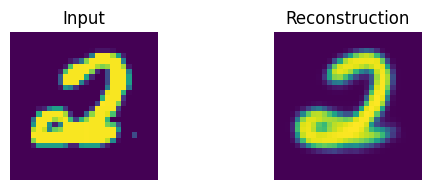

Loss train: 100.82676379394532



  0%|          | 0/313 [00:00<?, ?it/s]

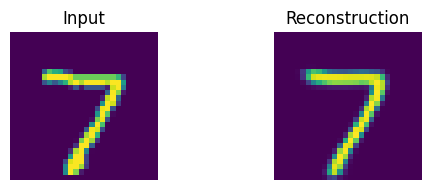

Loss valid: 99.92151137281911


Epoch: 8


  0%|          | 0/1875 [00:00<?, ?it/s]

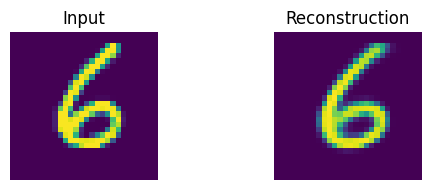

Loss train: 99.59666120605469



  0%|          | 0/313 [00:00<?, ?it/s]

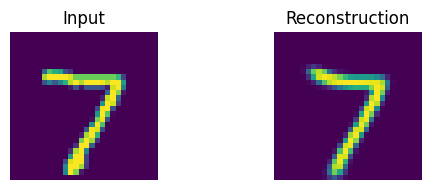

Loss valid: 97.8505684362052


Epoch: 9


  0%|          | 0/1875 [00:00<?, ?it/s]

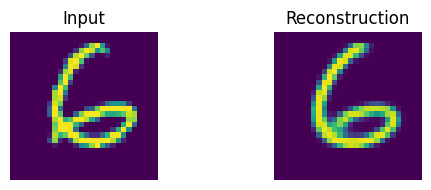

Loss train: 98.67347915852865



  0%|          | 0/313 [00:00<?, ?it/s]

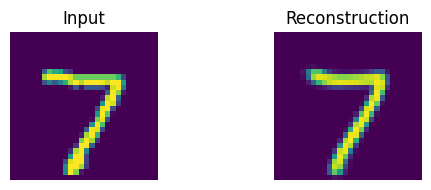

Loss valid: 96.81160606896154


Epoch: 10


  0%|          | 0/1875 [00:00<?, ?it/s]

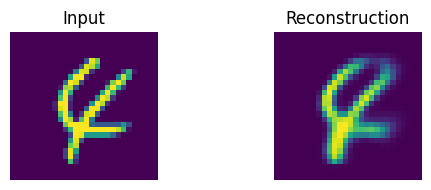

Loss train: 98.06324782714844



  0%|          | 0/313 [00:00<?, ?it/s]

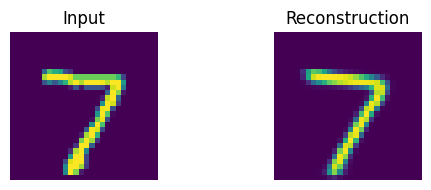

Loss valid: 96.7321764424967



In [ ]:
autoencoder, autoencoder_score = train_func(autoencoder, 10, dataloaders_mnist, optimizer, criterion)

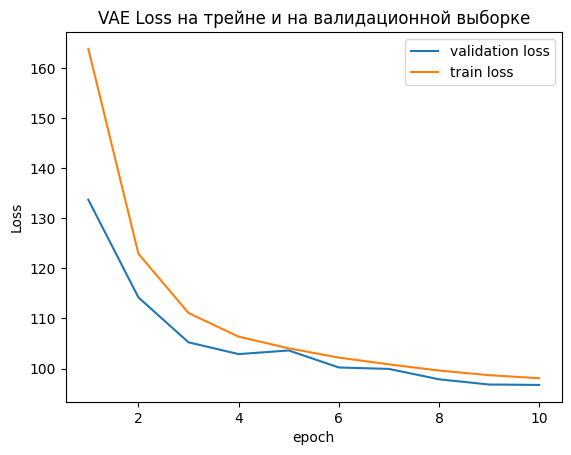

In [ ]:
plt.plot(range(1, 11), autoencoder_score['val_loss'], label='validation loss')
plt.plot(range(1, 11), autoencoder_score['train_loss'], label='train loss')

plt.title('VAE Loss на трейне и на валидационной выборке')
plt.xlabel('epoch')
plt.ylabel('Loss')
plt.legend()

Давайте попробуем проделать для VAE то же, что и с обычным автоэнкодером -- подсунуть decoder'у из VAE случайные векторы из нормального распределения и посмотреть, какие картинки получаются:

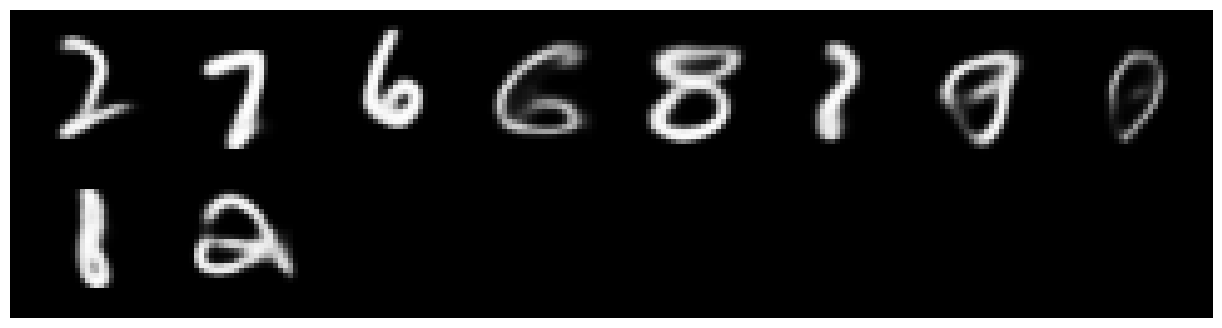

In [ ]:
# вспомните про замечание из этого же пункта обычного AE про распределение латентных переменных
z = np.array([np.random.normal(0, 1, 256) for i in range(10)]).astype(np.float32)
output = autoencoder.decoder(torch.from_numpy(z).to(DEVICE))
show_images_grid(output)

> В целом получаются разумные ответы, но некоторые либо трудно разглядеть, либо не существующие цифры

## 2.2. Latent Representation (2 балла)

Давайте посмотрим, как латентные векторы картинок цифр выглядят в пространстве.
Ваша задача -- изобразить латентные векторы картинок точками в двумерном просторанстве.

Это позволит оценить, насколько плотно распределены латентные векторы изображений цифр в пространстве.

Плюс давайте сделаем такую вещь: покрасим точки, которые соответствуют картинкам каждой цифры, в свой отдельный цвет

Подсказка: красить -- это просто =) У plt.scatter есть параметр c (color), см. в документации.


Итак, план:
1. Получить латентные представления картинок тестового датасета
2. С помощтю `TSNE` (есть в `sklearn`) сжать эти представления до размерности 2 (чтобы можно было их визуализировать точками в пространстве)
3. Визуализировать полученные двумерные представления с помощью `matplotlib.scatter`, покрасить разными цветами точки, соответствующие картинкам разных цифр.

In [ ]:
def get_latents_vae(autoencoder, dataloader):
  autoencoder.eval()
  latents = []
  labels = []
  with torch.no_grad():
    for X_batch, y_batch in dataloader:
      X_batch = X_batch.to(DEVICE)
      _, mu, logvar  = autoencoder(X_batch)
      latents.append(mu.cpu())
      labels.append(y_batch)

  latents = torch.cat(latents, dim=0)
  labels = torch.cat(labels, dim=0)
  return latents, labels

In [ ]:
latents_mnist, labels_mnist = get_latents_vae(autoencoder, test_loader)

In [ ]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    n_iter=1000,
    random_state=42
)

latents_2d = tsne.fit_transform(latents_mnist.numpy())

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


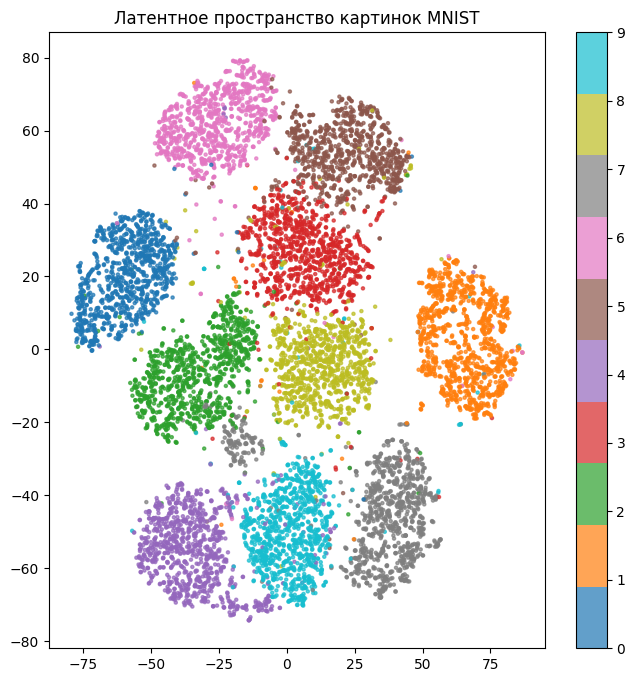

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
scatter = plt.scatter(
  latents_2d[:, 0],
  latents_2d[:, 1],
  c=labels_mnist.numpy(),
  cmap="tab10",
  s=5,
  alpha=0.7
)

plt.colorbar(scatter, ticks=range(10))
plt.title("Латентное пространство картинок MNIST")
plt.show()

Что вы думаете о виде латентного представления?

> Видно, что латентное распределение имеет четкие кластеры для каждой цифры. Некоторая часть цифр 7 прибилась к кластеру цифры 2, это можно объяснить визуальным сходством цифр.

__Congrats v2.0!__

## 2.3. Conditional VAE (6 баллов)


Мы уже научились обучать обычный AE на датасете картинок и получать новые картинки, используя генерацию шума и декодер.
Давайте теперь допустим, что мы обучили AE на датасете MNIST и теперь хотим генерировать новые картинки с числами с помощью декодера (как выше мы генерили рандомные лица).
И вот нам понадобилось сгенерировать цифру 8, и мы подставляем разные варианты шума, но восьмерка никак не генерится:(

Хотелось бы добавить к нашему AE функцию "выдай мне рандомное число из вот этого вот класса", где классов десять (цифры от 0 до 9 образуют десять классов).  Conditional AE — так называется вид автоэнкодера, который предоставляет такую возможность. Ну, название "conditional" уже говорит само за себя.

И в этой части задания мы научимся такие обучать.

### Архитектура

На картинке ниже представлена архитектура простого Conditional VAE.

По сути, единственное отличие от обычного -- это то, что мы вместе с картинкой в первом слое энкодера и декодера передаем еще информацию о классе картинки.

То есть, в первый (входной) слой энкодера подается конкатенация картинки и информации о классе (например, вектора из девяти нулей и одной единицы). В первый слой декодера подается конкатенация латентного вектора и информации о классе.


![alt text](https://sun9-63.userapi.com/impg/Mh1akf7mfpNoprrSWsPOouazSmTPMazYYF49Tw/djoHNw_9KVA.jpg?size=1175x642&quality=96&sign=e88baec5f9bb91c8443fba31dcf0a4df&type=album)

![alt text](https://sun9-73.userapi.com/impg/UDuloLNKhzTBYAKewgxke5-YPsAKyGOqA-qCRg/MnyCavJidxM.jpg?size=1229x651&quality=96&sign=f2d21bfacc1c5755b76868dc4cfef39c&type=album)



На всякий случай: это VAE, то есть, latent у него все еще состоит из mu и sigma

Таким образом, при генерации новой рандомной картинки мы должны будем передать декодеру сконкатенированные латентный вектор и класс картинки.

P.S. Также можно передавать класс картинки не только в первый слой, но и в каждый слой сети. То есть на каждом слое конкатенировать выход из предыдущего слоя и информацию о классе.

In [ ]:
def one_hot(labels, num_classes=10):
    return torch.nn.functional.one_hot(labels, num_classes).float()

In [ ]:
class Encoder(nn.Module):
  def __init__(self, in_channels=1, base_ch=64, latent_dim=256, num_classes=10):
    super().__init__()

    self.block0 = EncoderBlock(in_channels, base_ch, 2)
    self.block1 = EncoderBlock(base_ch, base_ch * 2, 2)
    self.block2 = EncoderBlock(base_ch * 2, base_ch * 4, 3)
    self.block3 = EncoderBlock(base_ch * 4, base_ch * 8, 3)

    self.pool = nn.AdaptiveAvgPool2d((1, 1))
    self.flatten = nn.Flatten()

    self.fc = nn.Linear(base_ch * 8 + num_classes, 512)
    self.fc_mu = nn.Linear(512, latent_dim)
    self.fc_logvar = nn.Linear(512, latent_dim)

  def forward(self, x, y):
    x = self.block0(x)
    x = self.block1(x)
    x = self.block2(x)
    x = self.block3(x)

    x = self.pool(x)
    x = self.flatten(x)

    x = torch.cat([x, y], dim=1)
    h = self.fc(x)

    mu = self.fc_mu(h)
    logvar = self.fc_logvar(h)

    return mu, logvar

In [ ]:
class Decoder(nn.Module):
  def __init__(self, latent_dim=256, out_channels=1, base_ch=64, num_classes=10):
    super().__init__()

    self.fc = nn.Linear(latent_dim + num_classes, base_ch * 8 * 4 * 4)

    self.net = nn.Sequential(
      nn.Unflatten(1, (base_ch * 8, 4, 4)),

      nn.Upsample(scale_factor=2),
      nn.Conv2d(base_ch * 8, base_ch * 4, 3, padding=1),
      nn.BatchNorm2d(base_ch * 4),
      nn.ReLU(True),

      nn.Upsample(scale_factor=2),
      nn.Conv2d(base_ch * 4, base_ch * 2, 3, padding=1),
      nn.BatchNorm2d(base_ch * 2),
      nn.ReLU(True),

      nn.Upsample(scale_factor=2),
      nn.Conv2d(base_ch * 2, base_ch, 3, padding=1),
      nn.BatchNorm2d(base_ch),
      nn.ReLU(True),

      nn.Conv2d(base_ch, out_channels, 3, padding=1),
      nn.Sigmoid()
    )

  def forward(self, z, y):
    z = torch.cat([z, y], dim=1)
    x = self.fc(z)
    x = self.net(x)
    return x[:, :, :28, :28]

In [ ]:
class CVAE(nn.Module):
  def __init__(self, in_channels=1, out_channels=1, base_ch=64, latent_dim=256, num_classes=10):
    super().__init__()

    self.encoder = Encoder(in_channels, base_ch, latent_dim, num_classes)
    self.decoder = Decoder(latent_dim, out_channels, base_ch, num_classes)

  def forward(self, x, y):
    mu, logvar = self.encoder(x, y)
    z = reparameterize(mu, logvar)
    recon = self.decoder(z, y)
    return recon, mu, logvar

In [ ]:
def fit_one_epoch(model, train_dataloader, optimizer, loss_func):
  model.train()
  avg_loss = 0
  visualized = False

  for X_batch, y_batch in tqdm(train_dataloader):
    X_batch = X_batch.to(DEVICE)
    y_batch = one_hot(y_batch).to(DEVICE)

    optimizer.zero_grad()
    outp, mu, logvar = model(X_batch, y_batch)

    if not visualized:
      visualized = True
      visualize(X_batch, outp)

    loss = loss_func(X_batch, mu, logvar, outp)
    loss.backward()
    optimizer.step()

    avg_loss += loss.item()

  return avg_loss / len(train_dataloader)

In [ ]:
def eval_one_epoch(model, val_dataloader, loss_func):
  model.eval()
  avg_loss = 0

  visualized = False

  with torch.no_grad():
    for X_batch, y_batch in tqdm(val_dataloader):
      X_batch = X_batch.to(DEVICE)
      y_batch = one_hot(y_batch).to(DEVICE)

      reconstructed, mu, logvar = model(X_batch, y_batch)

      loss = loss_func(X_batch, mu, logvar, reconstructed)

      avg_loss += loss.item()

      if not visualized:
        visualized = True
        visualize(X_batch, reconstructed)

    avg_loss = avg_loss / len(val_dataloader)

  return avg_loss

In [ ]:
criterion = loss_vae
autoencoder = CVAE()
optimizer = torch.optim.Adam(autoencoder.parameters(), lr = 1e-3)


Epoch: 1


  0%|          | 0/1875 [00:00<?, ?it/s]

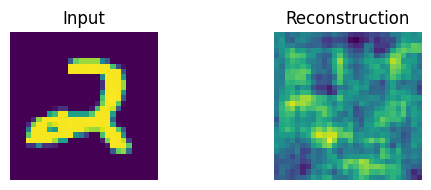

Loss train: 152.34285483398438



  0%|          | 0/313 [00:00<?, ?it/s]

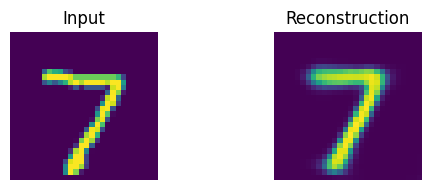

Loss valid: 123.20610392512604


Epoch: 2


  0%|          | 0/1875 [00:00<?, ?it/s]

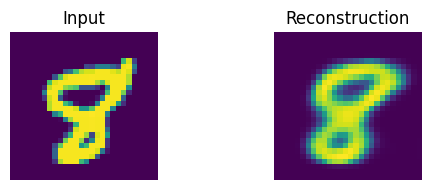

Loss train: 117.09604262288411



  0%|          | 0/313 [00:00<?, ?it/s]

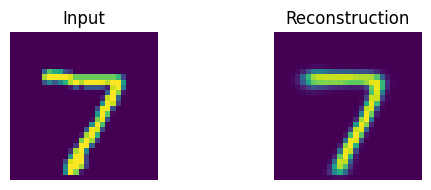

Loss valid: 109.49634868877764


Epoch: 3


  0%|          | 0/1875 [00:00<?, ?it/s]

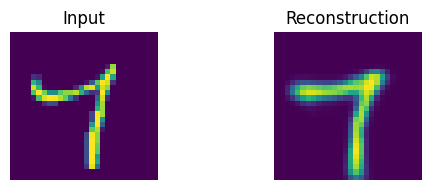

Loss train: 109.03323002522787



  0%|          | 0/313 [00:00<?, ?it/s]

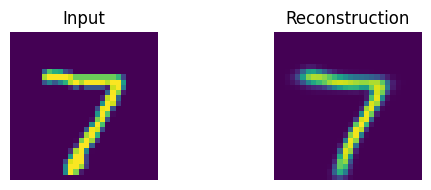

Loss valid: 107.49336069612838


Epoch: 4


  0%|          | 0/1875 [00:00<?, ?it/s]

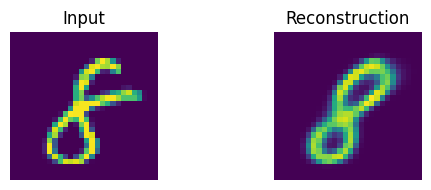

Loss train: 104.95343454182942



  0%|          | 0/313 [00:00<?, ?it/s]

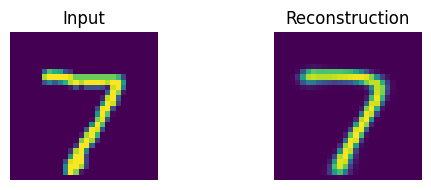

Loss valid: 103.35754928345116


Epoch: 5


  0%|          | 0/1875 [00:00<?, ?it/s]

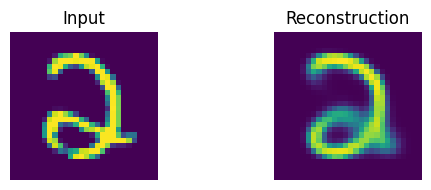

Loss train: 102.62722891845704



  0%|          | 0/313 [00:00<?, ?it/s]

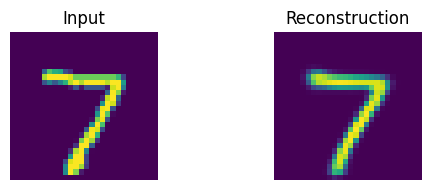

Loss valid: 100.53318908496406


Epoch: 6


  0%|          | 0/1875 [00:00<?, ?it/s]

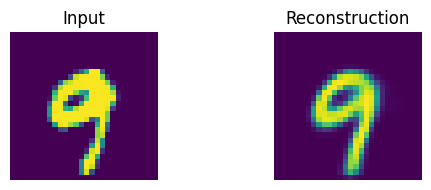

Loss train: 101.11358380940756



  0%|          | 0/313 [00:00<?, ?it/s]

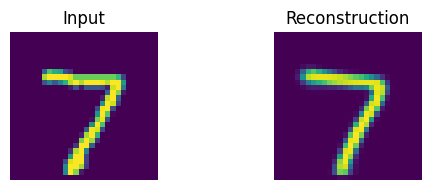

Loss valid: 99.13233523627821


Epoch: 7


  0%|          | 0/1875 [00:00<?, ?it/s]

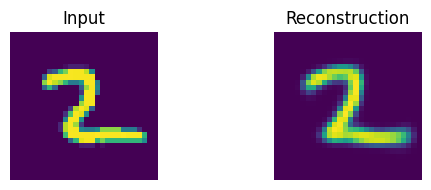

Loss train: 99.64763729654948



  0%|          | 0/313 [00:00<?, ?it/s]

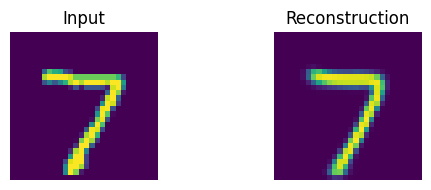

Loss valid: 97.89032267610105


Epoch: 8


  0%|          | 0/1875 [00:00<?, ?it/s]

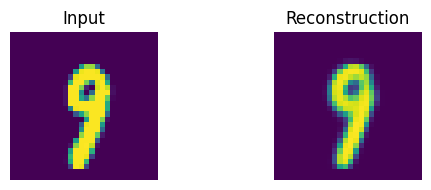

Loss train: 98.06382684326172



  0%|          | 0/313 [00:00<?, ?it/s]

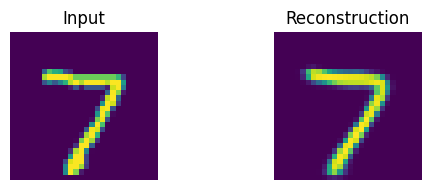

Loss valid: 96.53471550012168


Epoch: 9


  0%|          | 0/1875 [00:00<?, ?it/s]

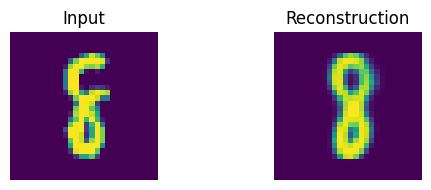

Loss train: 96.91503256835938



  0%|          | 0/313 [00:00<?, ?it/s]

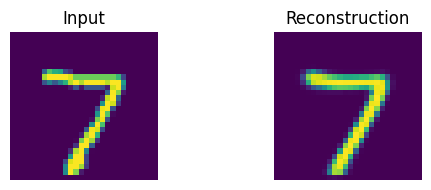

Loss valid: 95.2994896885686


Epoch: 10


  0%|          | 0/1875 [00:00<?, ?it/s]

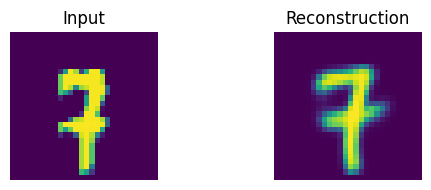

Loss train: 96.10414399007162



  0%|          | 0/313 [00:00<?, ?it/s]

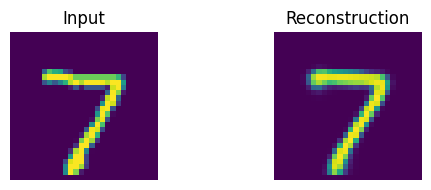

Loss valid: 94.59030365867737



In [ ]:
cv_autoencoder, cv_autoencoder_score = train_func(autoencoder, 10, dataloaders_mnist_with_labels, optimizer, criterion)

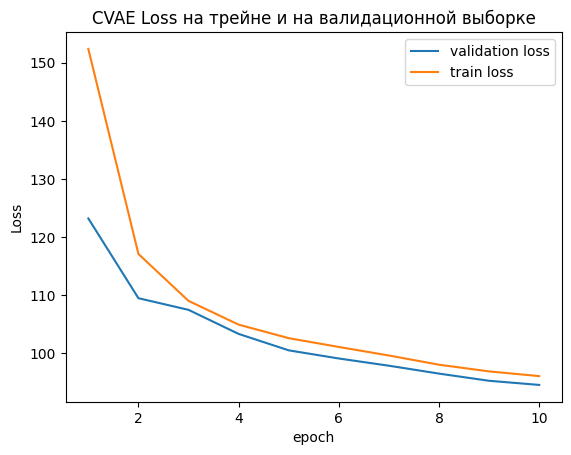

In [ ]:
plt.plot(range(1, 11), cv_autoencoder_score['val_loss'], label='validation loss')
plt.plot(range(1, 11), cv_autoencoder_score['train_loss'], label='train loss')

plt.title('CVAE Loss на трейне и на валидационной выборке')
plt.xlabel('epoch')
plt.ylabel('Loss')
plt.legend()

### Sampling


Тут мы будем сэмплировать из CVAE. Это прикольнее, чем сэмплировать из простого AE/VAE: тут можно взять один и тот же латентный вектор и попросить CVAE восстановить из него картинки разных классов!
Для MNIST вы можете попросить CVAE восстановить из одного латентного вектора, например, картинки цифры 5 и 7.

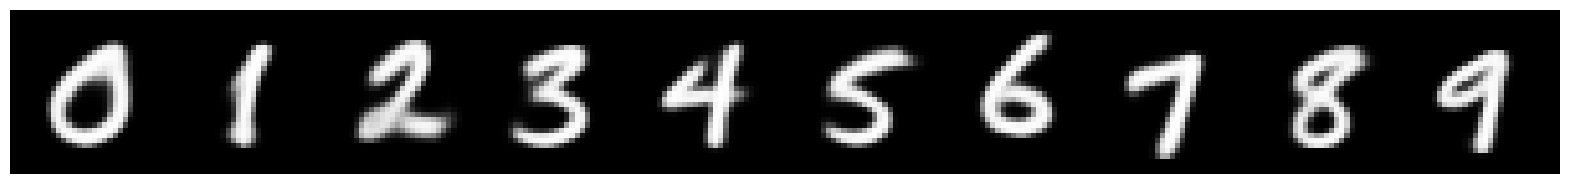

In [ ]:
z = torch.randn(1, 256).to(DEVICE)

images = []

with torch.no_grad():
  for digit in range(10):
    y = one_hot(torch.tensor([digit]), num_classes=10).float().to(DEVICE)
    img = cv_autoencoder.decoder(z, y)
    images.append(img)

images = torch.cat(images, dim=0)
show_images_grid(images, nrow=10)

Splendid! Вы великолепны!


### Latent Representations

Давайте посмотрим, как выглядит латентное пространство картинок в CVAE и сравним с картинкой для VAE =)

Опять же, нужно покрасить точки в разные цвета в зависимости от класса.

In [ ]:
def get_latents_and_labels(autoencoder, dataloader):
  autoencoder.eval()
  latents = []
  labels = []

  with torch.no_grad():
    for x, y in dataloader:
      x = x.to(DEVICE)
      y = one_hot(y).to(DEVICE)

      mu, logvar = autoencoder.encoder(x, y)

      latents.append(mu.cpu())
      labels.append(y.cpu())

  latents = torch.cat(latents, dim=0)
  labels = torch.cat(labels, dim=0)

  return latents.numpy(), labels.numpy()

In [ ]:
latents_vae, labels_vae = get_latents_and_labels(cv_autoencoder, test_loader)

In [ ]:
tsne = TSNE(
    n_components=2,
    perplexity=perplexity,
    n_iter=1000,
    init="pca",
    learning_rate="auto",
    random_state=42
)
z_vae_2d = tsne.fit_transform(latents_vae)

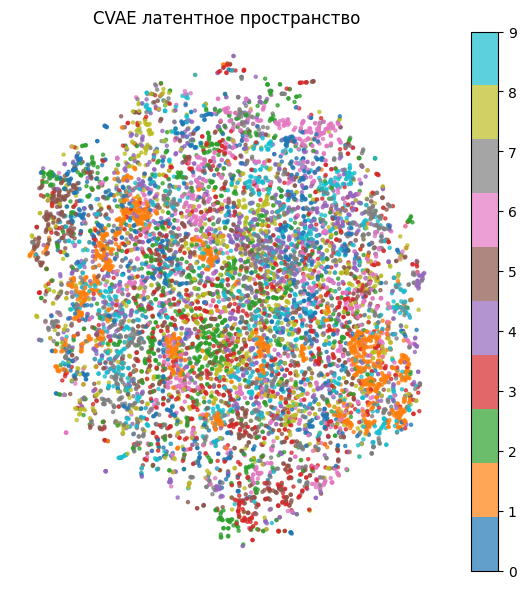

In [ ]:
labels_vae = labels_vae.argmax(axis=1)

plt.figure(figsize=(7, 7))

scatter = plt.scatter(
  z_vae_2d[:, 0],
  z_vae_2d[:, 1],
  c=labels_vae,
  cmap="tab10",
  s=5,
  alpha=0.7
)

plt.colorbar(scatter, ticks=range(10))
plt.title('CVAE латентное пространство')
plt.axis("off")
plt.show()

Что вы думаете насчет этой картинки? Отличается от картинки для VAE?

> Это латентное распределение уже хаотичное, нет четких кластеров. Т.к. классы известны, модель не оптимизирует лосс под них, поэтому все классы смешаны